In [62]:
import numpy as np 
import pandas as pd 
import os 
import cv2
import matplotlib.pyplot as plt 

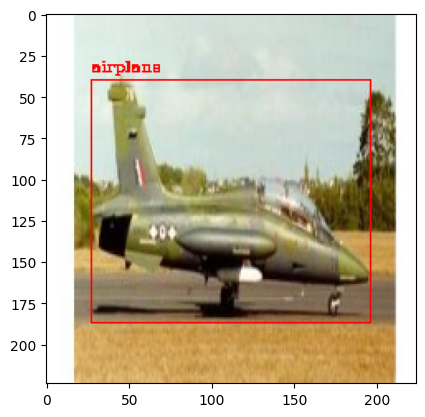

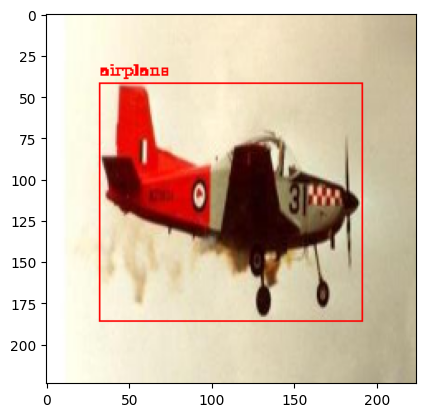

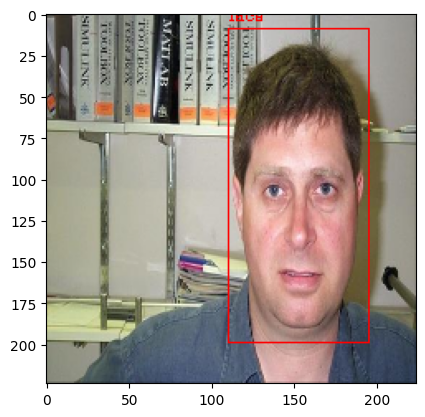

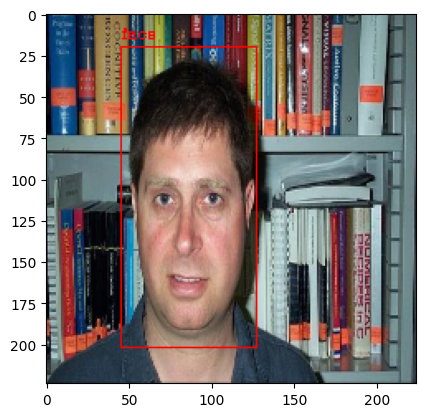

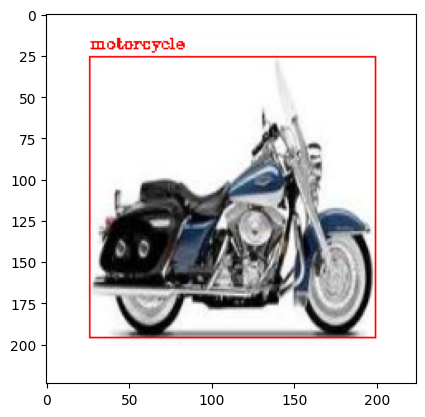

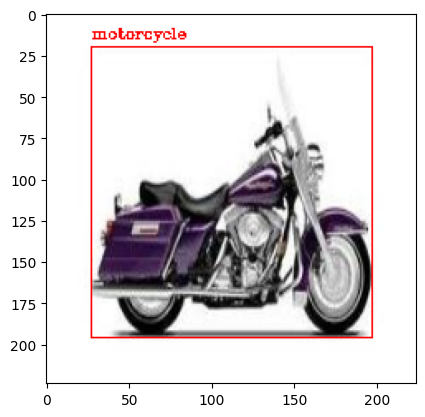

In [63]:
data_path = 'dataset/images'
annot_path =  'dataset/annotations'

img_size = 224


for folder in (os.listdir(data_path)):
    csv_name = folder +'.csv'
    annot_csv= os.path.join(annot_path, csv_name)

    annot_df = pd.read_csv(annot_csv)
    folder_image_path = os.path.join(data_path, folder)
    num = 0


    for image in (os.listdir(folder_image_path)):

        image_path = os.path.join(folder_image_path, image)
        
        img = cv2.cvtColor(cv2.imread(image_path),cv2.COLOR_BGR2RGB)
        h, w ,_ = img.shape

        img_resize = cv2.resize(img.copy(), (img_size, img_size))


        annot = annot_df[annot_df['image_name']== image].iloc[0,1:].tolist()

        annot[0] = int((annot[0]/w)*img_size)
        annot[1] = int((annot[1]/h)*img_size)
        annot[2] = int((annot[2]/w)*img_size)
        annot[3] = int((annot[3]/h)*img_size)





        num += 1

        if num <3:
            img_anot = cv2.rectangle(img_resize , annot[:2] , annot[2:], (255 , 0, 0), 1)
            img_anot = cv2.putText(img_anot , folder , (annot[0],annot[1]-5),cv2.FONT_HERSHEY_COMPLEX,0.3,color=(255,0,0))
            plt.imshow(img_anot)
            plt.show()




___________________________________________
